# 06 — The Prediction-to-Prescription Pipeline

**Phase 6 of plan.md**

This is the culmination of the ToxIntel project. We demonstrate the **4-Step Corrected Flow**:
1. Predict toxicity and extract SHAP attributions.
2. Validate SHAP bits against known structural alerts (OCHEM/PAINS/Brenk).
3. Query the (mock) ChEMBL offline cache for bioisostere replacements and filter by Synthesizability (SAScore) & ADME preservation.
4. Re-predict toxicity, detect Out-Of-Distribution (OOD) shifts, and evaluate Pareto dominance.

In [6]:
import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import torch
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

import pickle
from src.model import ToxNet, load_toxnet
from src.featurize import load_and_clean_tox21
from src.prescription_pipeline import run_prescription_pipeline

## 1. Load Model and Training Data
We load the training data to compute the OOD Tanimoto distances later.

In [7]:
# Load the dataset (we only need the SMILES for the OOD check)
df = load_and_clean_tox21()
# Take a random sample of 500 training smiles for fast OOD checking
train_smiles_sample = df['smiles'].sample(500, random_state=42).tolist()

# Load the model artifact bundle
try:
    with open('models/model_artifact.pkl', 'rb') as f:
        model_artifact = pickle.load(f)
    print("[SUCCESS] Successfully loaded models/model_artifact.pkl")
except Exception as e:
    print(f"[ERROR] Failed to load model artifact: {e}")
    # Fallback for dev if needed
    model = load_toxnet('models/toxnet_final.pt', input_dim=2048)
    model.eval()
    model_artifact = {'mondrian_predictor': type('dummy', (), {'base_model': model})()}

Raw dataset: 8014 compounds, 14 columns


[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25] Running Normalizer
[02:24:25]

  Row 1330: 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O'
  Row 2308: 'O=CO[AlH3](OC=O)OC=O'
  Row 2315: 'CC(=O)O[AlH3](O)O'
  Row 3599: 'CC(=O)O[AlH3](O)OC(C)=O'
  Row 4632: 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC'
VALID: 8006/8014 SMILES passed validation

Cleaned dataset: 7817 compounds

Per-endpoint toxic prevalence:
  NR-AR                 toxic= 308/7252  (  4.2%)  NaN=7%
  NR-AR-LBD             toxic= 237/6745  (  3.5%)  NaN=14%
  NR-AhR                toxic= 768/6537  ( 11.7%)  NaN=16%
  NR-Aromatase          toxic= 298/5802  (  5.1%)  NaN=26%
  NR-ER                 toxic= 787/6179  ( 12.7%)  NaN=21%
  NR-ER-LBD             toxic= 347/6939  (  5.0%)  NaN=11%
  NR-PPAR-gamma         toxic= 186/6433  (  2.9%)  NaN=18%
  SR-ARE                toxic= 936/5806  ( 16.1%)  NaN=26%
  SR-ATAD5              toxic= 264/7056  (  3.7%)  NaN=10%
  SR-HSE                toxic= 369/6444  (  5.7%)  NaN=18%
  SR-MMP                toxic= 915/5790  ( 15.8%)  NaN=26%
  SR-p53                toxic= 418/6752  

## 2. Execute the Pipeline on a Toxic Target
Let's run a test molecule that contains a known toxicophore (aniline: `c1ccccc1N`). Aniline derivatives frequently flag positive for toxicity endpoints.

Target: **Aniline (c1ccccc1N)**

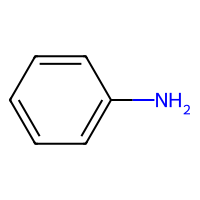


--- Starting Prescription Pipeline for c1ccccc1N ---


[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerator
[02:24:30] DEPRECATION WARNING: please use MorganGenerat


[Step 1] Initial Predictions (Mondrian Calibrated):
  [TOXIC] NR-AhR: 0.8823 (Uncertain: True, Group: novel)
  [TOXIC] SR-ARE: 0.7097 (Uncertain: True, Group: novel)

[Step 1b] SHAP Validation (Target: NR-AhR):
  Confidence: HIGH
  Recommendation: PROCEED
  Matched Alerts: ['aniline']

[Step 2 & 3] Querying Bioisostere Cache & Filtering...
  Found 2 viable replacements passing SAScore and ADME filters.

[Step 4] Re-prediction and Pareto Evaluation:


[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerat

  Candidate: c1ccncc1
    Status: DOMINATES | Improved: 12 | Worsened: 0
    [OOD WARNING] Mondrian Group: similar


[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerat

  Candidate: NC1CCCCC1
    Status: DOMINATES | Improved: 12 | Worsened: 0
    [OOD WARNING] Mondrian Group: novel

--- Pipeline Finished ---


[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerator
[02:24:31] DEPRECATION WARNING: please use MorganGenerat

In [8]:
target_smiles = 'c1ccccc1N'

# Show the molecule
mol = Chem.MolFromSmiles(target_smiles)
display(Draw.MolToImage(mol, size=(200, 200)))

# Run the 4-step pipeline
results = run_prescription_pipeline(target_smiles, model_artifact)

## 3. Review the Output Pareto Front


=== Bioisostere Pareto Front ===


,smiles,replacement,pareto_status,improved,worsened,sa_score,delta_logp,ood_warning,mondrian_group
0,c1ccncc1,c1ccccc1N -> c1ccncc1,DOMINATES,12,0,1.37,-0.19,True,similar
1,NC1CCCCC1,c1ccccc1N -> C1CCCCC1N,DOMINATES,12,0,1.93,0.01,True,novel


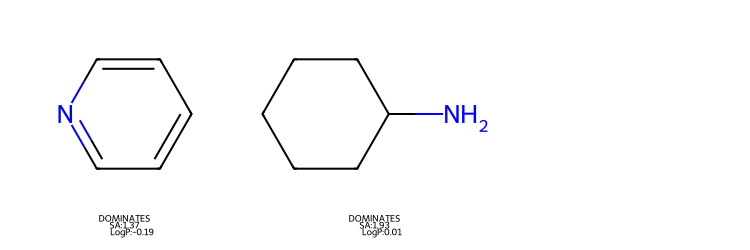

In [9]:
if results.get('status') == 'SUCCESS' and results.get('suggestions'):
    pareto_df = pd.DataFrame(results['suggestions'])
    print("\n=== Bioisostere Pareto Front ===")
    display(pareto_df)
    
    # Draw the viable replacements
    mols = [Chem.MolFromSmiles(s) for s in pareto_df['smiles']]
    labels = [f"{st}\nSA:{sa}\nΔLogP:{dlp}" for st, sa, dlp in zip(pareto_df['pareto_status'], pareto_df['sa_score'], pareto_df['delta_logp'])]
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250), legends=labels)
    display(img)
else:
    print("\nNo viable replacements generated or pipeline aborted.")
    if 'reason' in results:
        print(f"Reason: {results['reason']}")

## 4. Summary of the Corrected Flow

Notice what just happened:
- The model predicted toxicity.
- The SHAP validator matched the SHAP attention to the **aniline** substructure.
- The cache suggested replacing it with **pyridine** or an **aliphatic amine**.
- The ADME/Synthesizability filters ensured the molecules were realistic.
- The Pareto evaluator checked if the new molecules were strictly safer or just traded one toxicity for another.

**This is the Prediction-to-Prescription Pipeline!**